### code for finding and verification of logical Hadamard

H_L |0_L> mags: 0.7071067811865461 0.7071067811865461 target ~ 0.7071067811865475 0.7071067811865475
H_L |1_L> mags: 0.7071067811865461 0.7071067811865461 target ~ 0.7071067811865475 0.7071067811865475
H_L X_L H_L^† -> XZZZZZXIIIII
H_L Z_L H_L^† -> XXXXXXXXXXXX
H_L swaps X_L and Z_L up to sign: True


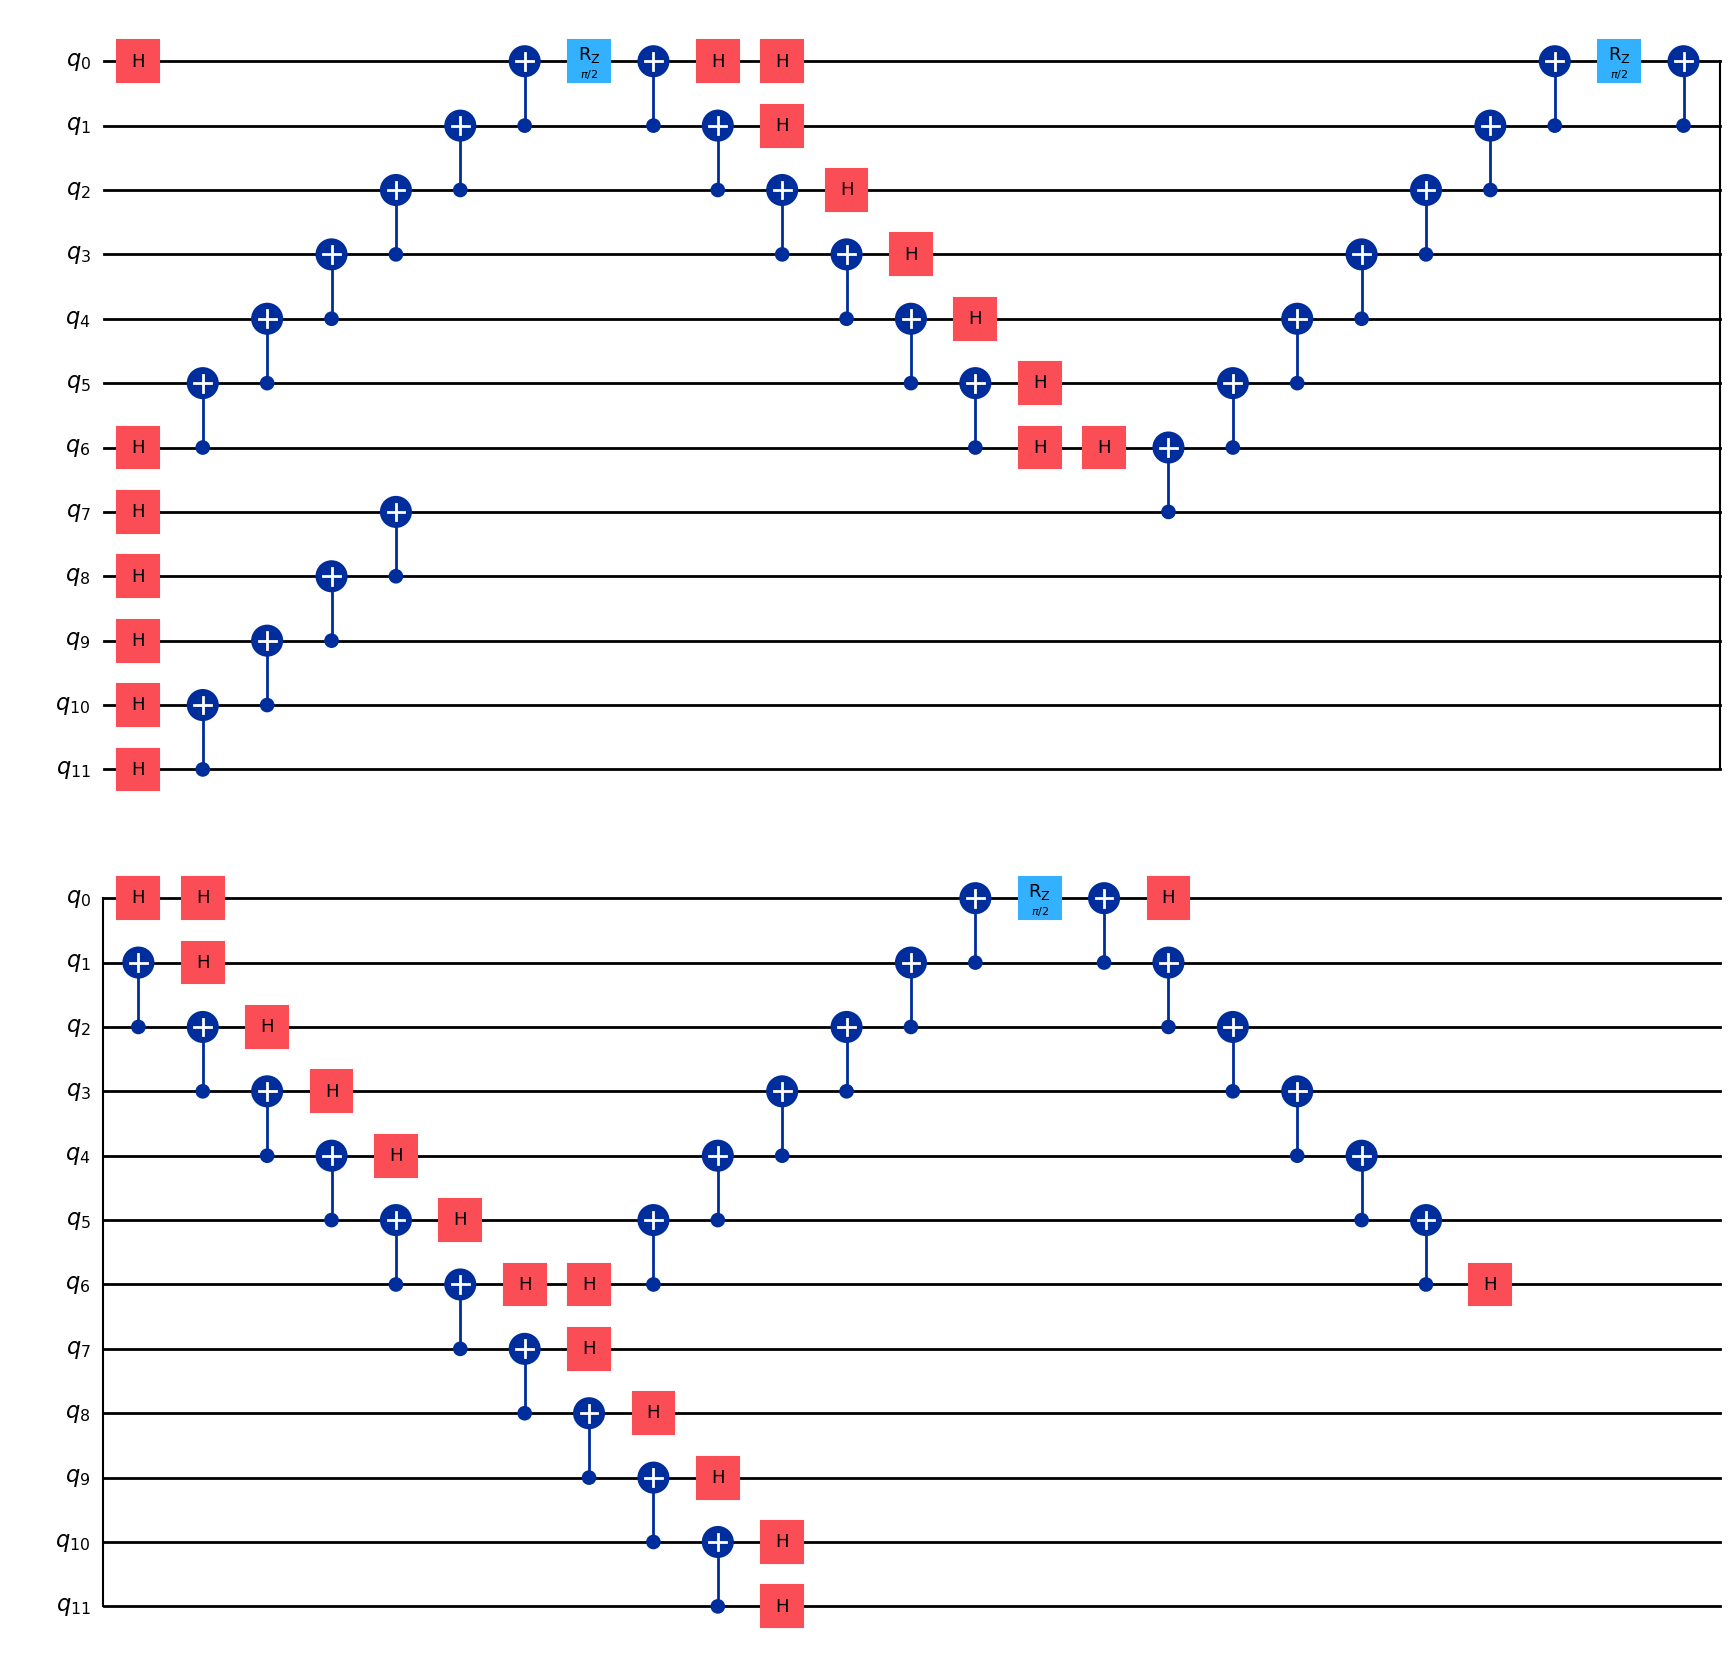

In [2]:
# ===== Part 1: H_L only =====
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, Pauli, Operator, Clifford
from qiskit.circuit.library import PauliEvolutionGate

# Parameters
L = 12
theta = np.pi / 4
steps = L // 4

# Helpers: label orientation
def pauli_from_label(label: str) -> Pauli:
    return Pauli(label[::-1])
def pauli_to_label(p: Pauli) -> str:
    return p.to_label()[::-1]

# Build U = B·A and prepare |0_L>
def circuit_for_A_xx_ring(L, theta, periodic=True):
    qc = QuantumCircuit(L, name="A_xx_RXX")
    phi = 2 * theta  # rxx(phi) = exp(-i phi/2 XX)
    if periodic:
        for j in range(L):
            qc.rxx(phi, j, (j + 1) % L)
    else:
        for j in range(L - 1):
            qc.rxx(phi, j, j + 1)
    return qc
def circuit_for_B(L, theta):
    qc = QuantumCircuit(L, name="B_field_Z")
    for j in range(L):
        qc.rz(2 * theta, j)  # rz(2θ) = exp(-i θ Z)
    return qc
def build_U_layer(L, theta, periodic=True):
    A = circuit_for_A_xx_ring(L, theta, periodic)
    B = circuit_for_B(L, theta)
    qc = QuantumCircuit(L, name="U")
    
    qc.compose(A, inplace=True)
    qc.compose(B, inplace=True)
    return qc

U_layer = build_U_layer(L, theta, periodic=True)
psi = Statevector.from_label("0" * L)
for _ in range(steps):
    psi = psi.evolve(U_layer)
ket0L = psi

# Logical Paulis and basis
XL_str = "X" * L
ZL_str = "XZZZZZXIIIII"
X_L_op = SparsePauliOp(pauli_from_label(XL_str))
Z_L_op = SparsePauliOp(pauli_from_label(ZL_str))
ket1L = ket0L.evolve(Operator(X_L_op))

# Build H_L = R_Z(π/2) R_X(π/2) R_Z(π/2) as a circuit
def R_logical(pauli_op: SparsePauliOp, theta: float) -> PauliEvolutionGate:
    return PauliEvolutionGate(pauli_op, time=theta/2.0)  # exp(-i (θ/2) P)
def build_HL_logical(L, X_L_op, Z_L_op):
    qc = QuantumCircuit(L, name="H_L")
    qc.append(R_logical(Z_L_op, np.pi/2), range(L))
    qc.append(R_logical(X_L_op, np.pi/2), range(L))
    qc.append(R_logical(Z_L_op, np.pi/2), range(L))
    return qc

H_L_circ = build_HL_logical(L, X_L_op, Z_L_op)
H_L_cliff = Clifford(H_L_circ)

# Utilities
def overlap(a: Statevector, b: Statevector) -> complex:
    return complex(np.vdot(a.data, b.data))
def proj_to_code(state, b0, b1):
    return overlap(b0, state), overlap(b1, state)
def equal_up_to_phase(p: Pauli, label: str) -> bool:
    lab = pauli_to_label(p)
    return lab == label or pauli_to_label(-p) == label

# Amplitude checks
psi_H0 = ket0L.evolve(H_L_circ)
psi_H1 = ket1L.evolve(H_L_circ)
a0, a1 = proj_to_code(psi_H0, ket0L, ket1L)
b0, b1 = proj_to_code(psi_H1, ket0L, ket1L)
print("H_L |0_L> mags:", abs(a0), abs(a1), "target ~", 1/np.sqrt(2), 1/np.sqrt(2))
print("H_L |1_L> mags:", abs(b0), abs(b1), "target ~", 1/np.sqrt(2), 1/np.sqrt(2))

# Conjugation checks (Clifford)
XL_after = Pauli(pauli_from_label(XL_str)).evolve(H_L_cliff)
ZL_after = Pauli(pauli_from_label(ZL_str)).evolve(H_L_cliff)
print("H_L X_L H_L^† ->", pauli_to_label(XL_after))
print("H_L Z_L H_L^† ->", pauli_to_label(ZL_after))
print("H_L swaps X_L and Z_L up to sign:",
      equal_up_to_phase(XL_after, ZL_str) and equal_up_to_phase(ZL_after, XL_str))

# Draw decomposed H_L
H_L_circ.decompose().draw('mpl')


In [3]:
import numpy as np
from qiskit.quantum_info import Operator
from qiskit.circuit.library import RXGate, RZGate, HGate

# Define rotation gates
RZ_pi_2 = RZGate(np.pi/2)
RX_pi_2 = RXGate(np.pi/2)
H = HGate()

# Compute the product U = RZ(pi/2) * RX(pi/2) * RZ(pi/2)
U = Operator(RZ_pi_2) @ Operator(RX_pi_2) @ Operator(RZ_pi_2)

# Get matrix for H
H_mat = Operator(H)

# Check proportionality: U = global_phase * H
# Calculate global phase factor
global_phase = (U.data[0,0] / H_mat.data[0,0])

# Divide U by global_phase to check equality with H
U_normalized = U.data / global_phase

print("Global phase factor:", global_phase)
print("U normalized:\n", U_normalized)
print("Hadamard matrix:\n", H_mat.data)

# Check if equal up to numerical precision
print("Are matrices equal (up to global phase)?", np.allclose(U_normalized, H_mat.data))


Global phase factor: -1.0000000000000002j
U normalized:
 [[ 0.70710678-0.j  0.70710678-0.j]
 [ 0.70710678-0.j -0.70710678+0.j]]
Hadamard matrix:
 [[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]
Are matrices equal (up to global phase)? True


In [4]:
ket_plus_L = (ket0L.data + ket1L.data) / np.sqrt(2)
ket_minus_L = (ket0L.data - ket1L.data) / np.sqrt(2)
from qiskit.quantum_info import Statevector

ket_plus_L = Statevector(ket_plus_L)
ket_minus_L = Statevector(ket_minus_L)
psi_H0 = ket0L.evolve(H_L_circ)
psi_H1 = ket1L.evolve(H_L_circ)
overlap_plus_0 = abs(np.vdot(ket_plus_L.data, psi_H0.data))**2
overlap_minus_1 = abs(np.vdot(ket_minus_L.data, psi_H1.data))**2

print(f"Fidelity of H_L |0_L> with |+_L>: {overlap_plus_0:.6f}")
print(f"Fidelity of H_L |1_L> with |-_L>: {overlap_minus_1:.6f}")
print("⟨+_L|+_L⟩ =", np.vdot(ket_plus_L.data, ket_plus_L.data).real)
print("⟨-_L|-_L⟩ =", np.vdot(ket_minus_L.data, ket_minus_L.data).real)
print("|⟨+_L|-_L⟩| =", abs(np.vdot(ket_plus_L.data, ket_minus_L.data)))


Fidelity of H_L |0_L> with |+_L>: 1.000000
Fidelity of H_L |1_L> with |-_L>: 1.000000
⟨+_L|+_L⟩ = 1.0000000000000002
⟨-_L|-_L⟩ = 1.0000000000000002
|⟨+_L|-_L⟩| = 0.0
